<a href="https://colab.research.google.com/github/syed-rayyanadil/pointnet-foldingnet-completion/blob/main/evaluation_and_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.9 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/syed-rayyanadil/pointnet-foldingnet-completion.git
%cd pointnet-foldingnet-completion

Cloning into 'pointnet-foldingnet-completion'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 117 (delta 45), reused 101 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 517.53 KiB | 3.78 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/pointnet-foldingnet-completion


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp "/content/drive/MyDrive/Point Cloud Completion with Uncertainty Estimation/data/ModelNet40.zip" /content/
!unzip -q /content/ModelNet40.zip -d /content/pointnet-foldingnet-completion/data/

In [5]:
import os
import torch

# Copy checkpoint directly from your Google Drive folder into local runtime
checkpoint_drive_path = "/content/drive/MyDrive/Point Cloud Completion with Uncertainty Estimation/best_model_200_epoch.pth"
checkpoint_local_path = "checkpoints/best_model_200_epoch.pth"

os.makedirs("checkpoints", exist_ok=True)
!cp "{checkpoint_drive_path}" "{checkpoint_local_path}"
print("Loaded checkpoint to:", checkpoint_local_path)

Loaded checkpoint to: checkpoints/best_model_200_epoch.pth


In [6]:
!python eval.py --checkpoint checkpoints/best_model_200_epoch.pth --data_dir /content/pointnet-foldingnet-completion/data/ModelNet40 --categories chair

Evaluation Device: cpu
Test Dataset: [chair] - 100 samples (7 batches)
Loaded checkpoint: checkpoints/best_model_200_epoch.pth

Evaluating on test split...

 EVALUATION RESULTS [CHAIR]
 Test Samples       : 100
 Mean Chamfer Loss  : 0.315719
 Std Chamfer Loss   : 0.037670



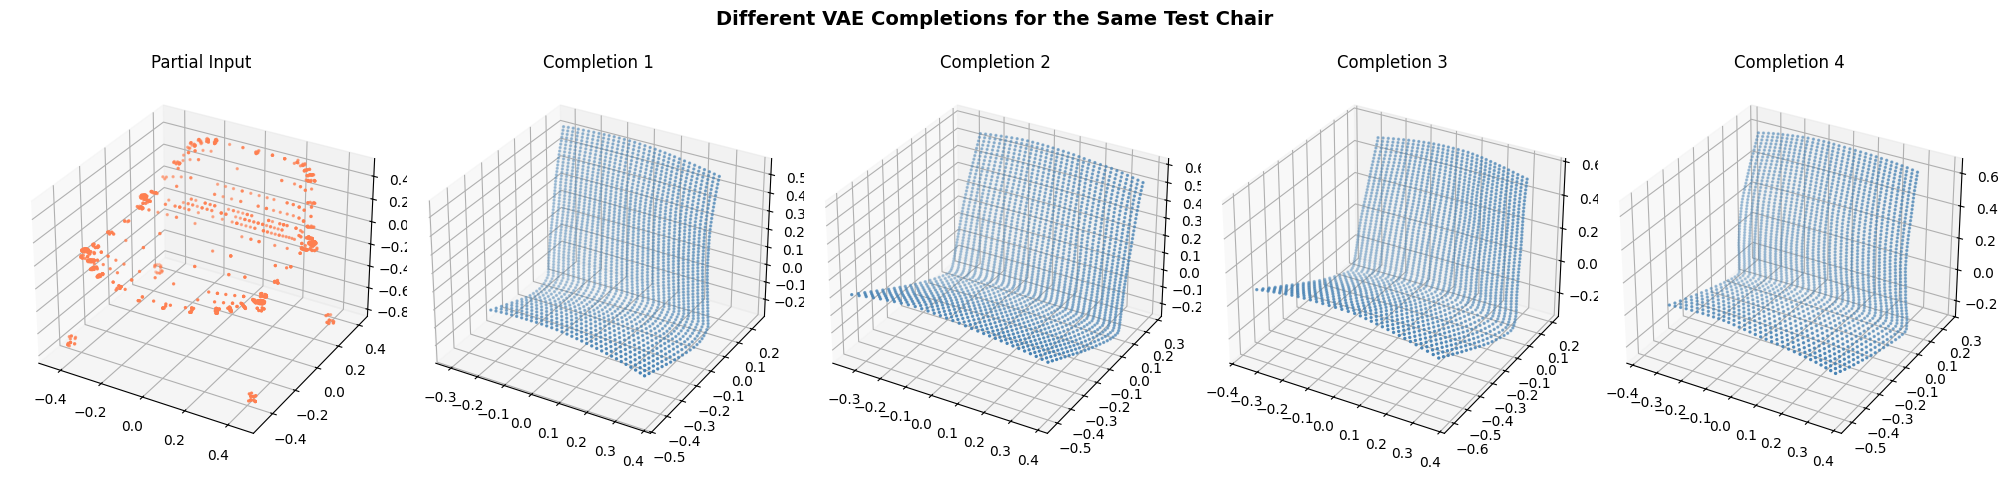

In [7]:
import torch
import matplotlib.pyplot as plt
from data.dataset import ModelNetDataset
from src.models.model import PointCloudCompletion

# 1. Load model and checkpoint on CPU/GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PointCloudCompletion(encoder_type="pointnet++").to(device)
model.load_state_dict(torch.load('checkpoints/best_model_200_epoch.pth', map_location=device))
model.eval()

# 2. Get one partial chair from test split
dataset = ModelNetDataset(
    root_dir="/content/pointnet-foldingnet-completion/data/ModelNet40",
    category=["chair"],
    split="test"
)
partial_sample, _ = dataset[0]
partial = partial_sample.unsqueeze(0).to(device)

# 3. Generate 4 different VAE completions
completions = []
with torch.no_grad():
    for _ in range(4):
        output = model(partial)
        completions.append(output["predicted_cloud"].squeeze(0).cpu().numpy())

# 4. Plot side-by-side in 3D
fig = plt.figure(figsize=(20, 5))
fig.suptitle("Different VAE Completions for the Same Test Chair", fontsize=14, fontweight="bold")

# Panel 1: Partial Input
ax0 = fig.add_subplot(151, projection='3d')
ax0.scatter(partial_sample[:, 0], partial_sample[:, 1], partial_sample[:, 2], c='coral', s=2)
ax0.set_title("Partial Input")

# Panels 2-5: The 4 completions
for i in range(4):
    ax = fig.add_subplot(150 + (i + 2), projection='3d')
    ax.scatter(completions[i][:, 0], completions[i][:, 1], completions[i][:, 2], c='steelblue', s=2)
    ax.set_title(f"Completion {i+1}")

plt.tight_layout()
plt.show()